# R-CNN Обнаружение и Классификация Объектов

Этот ноутбук реализует модель R-CNN (Region-based Convolutional Neural Network) для обнаружения объектов на изображениях.

## Основные возможности:
- Загрузка данных из Google Drive
- Обучение модели на пользовательском датасете
- Валидация и тестирование модели
- Визуализация метрик и результатов
- Сохранение и загрузка обученной модели

## 1. Установка необходимых библиотек

In [1]:
# Установка необходимых библиотек
!pip install torch torchvision
!pip install matplotlib pillow numpy
!pip install albumentations
!pip install tqdm

## 2. Импорт библиотек

In [2]:
# Импорт основных библиотек
import torch
import torch.nn as nn
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os
import glob
from tqdm import tqdm
import json
import random
from collections import defaultdict

# Установка seed для воспроизводимости результатов
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Проверка доступности GPU
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f'Используемое устройство: {device}')

Используемое устройство: cuda


## 3. Подключение Google Drive

In [3]:
# Монтирование Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ВАЖНО: Укажите путь к вашему датасету в Google Drive
# Структура должна быть следующей:
# dataset_path/
#   ├── train/
#   │   ├── images/  (*.png файлы)
#   │   └── labels/  (*.txt файлы)
#   ├── val/
#   │   ├── images/
#   │   └── labels/
#   └── test/
#       ├── images/
#       └── labels/

# Укажите путь к вашему датасету
DATASET_PATH = '/content/drive/MyDrive/dataset'  # Измените на ваш путь

# Пути к подпапкам
TRAIN_IMAGES = os.path.join(DATASET_PATH, 'train/images')
TRAIN_LABELS = os.path.join(DATASET_PATH, 'train/labels')
VAL_IMAGES = os.path.join(DATASET_PATH, 'val/images')
VAL_LABELS = os.path.join(DATASET_PATH, 'val/labels')
TEST_IMAGES = os.path.join(DATASET_PATH, 'test/images')
TEST_LABELS = os.path.join(DATASET_PATH, 'test/labels')

# Путь для сохранения модели и результатов
OUTPUT_PATH = '/content/drive/MyDrive/rcnn_output'
os.makedirs(OUTPUT_PATH, exist_ok=True)

print('Google Drive успешно подключен!')
print(f'Путь к датасету: {DATASET_PATH}')
print(f'Путь для сохранения результатов: {OUTPUT_PATH}')

Mounted at /content/drive
Google Drive успешно подключен!
Путь к датасету: /content/drive/MyDrive/dataset
Путь для сохранения результатов: /content/drive/MyDrive/rcnn_output


## 4. Класс Dataset для работы с данными в формате YOLO

In [4]:
class ObjectDetectionDataset(Dataset):
    """
    Датасет для обнаружения объектов.
    Загружает изображения и аннотации в формате YOLO.

    Формат аннотаций YOLO:
    class_id x_center y_center width height
    где все координаты нормализованы (от 0 до 1)
    """

    def __init__(self, images_dir, labels_dir, transforms=None):
        """
        Args:
            images_dir: путь к папке с изображениями
            labels_dir: путь к папке с аннотациями
            transforms: трансформации для аугментации данных
        """
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transforms = transforms

        # Получение списка всех изображений
        self.image_files = sorted(glob.glob(os.path.join(images_dir, '*.png')))

        if len(self.image_files) == 0:
            raise ValueError(f'Изображения не найдены в {images_dir}')

        print(f'Загружено {len(self.image_files)} изображений из {images_dir}')

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # Загрузка изображения
        img_path = self.image_files[idx]
        image = Image.open(img_path).convert('RGB')
        img_width, img_height = image.size

        # Получение пути к файлу с аннотациями
        label_filename = os.path.basename(img_path).replace('.png', '.txt')
        label_path = os.path.join(self.labels_dir, label_filename)

        boxes = []
        labels = []

        # Чтение аннотаций
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    # Парсинг строки: class_id x_center y_center width height
                    parts = line.strip().split()
                    if len(parts) == 5:
                        class_id = int(parts[0])
                        x_center = float(parts[1])
                        y_center = float(parts[2])
                        width = float(parts[3])
                        height = float(parts[4])

                        # Преобразование из формата YOLO в формат [x_min, y_min, x_max, y_max]
                        x_min = (x_center - width / 2) * img_width
                        y_min = (y_center - height / 2) * img_height
                        x_max = (x_center + width / 2) * img_width
                        y_max = (y_center + height / 2) * img_height

                        # Проверка корректности координат
                        x_min = max(0, min(x_min, img_width))
                        y_min = max(0, min(y_min, img_height))
                        x_max = max(0, min(x_max, img_width))
                        y_max = max(0, min(y_max, img_height))

                        # Проверка, что бокс имеет положительную площадь
                        if x_max > x_min and y_max > y_min:
                            boxes.append([x_min, y_min, x_max, y_max])
                            # +1 потому что 0 - это фон в R-CNN
                            labels.append(class_id + 1)

        # Если нет боксов, создаем пустые тензоры
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)

        # Преобразование изображения в тензор
        image = torchvision.transforms.functional.to_tensor(image)

        # Создание словаря с целевыми данными
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([idx])
        }

        return image, target

In [5]:
# Диагностика данных: проверка диапазона классов
import glob
import os

def check_dataset_classes(labels_dir):
    """Проверка диапазона классов в датасете"""
    label_files = glob.glob(os.path.join(labels_dir, '*.txt'))
    all_classes = set()

    for label_file in label_files:
        with open(label_file, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    all_classes.add(class_id)

    return sorted(all_classes)

# Проверка всех выборок
print("Проверка классов в датасете...")
print("-" * 50)

train_classes = check_dataset_classes(TRAIN_LABELS)
print(f"Train классы: {train_classes}")

val_classes = check_dataset_classes(VAL_LABELS)
print(f"Val классы: {val_classes}")

test_classes = check_dataset_classes(TEST_LABELS)
print(f"Test классы: {test_classes}")

all_classes = sorted(set(train_classes + val_classes + test_classes))
print("-" * 50)
print(f"Все уникальные классы: {all_classes}")
print(f"Максимальный class_id: {max(all_classes)}")
print(f"Минимальный class_id: {min(all_classes)}")

# Вычисление правильного NUM_CLASSES
correct_num_classes = max(all_classes) + 2  # +1 для background, +1 т.к. индексы с 0
print(f"\n⚠️ ВАЖНО: NUM_CLASSES должен быть = {correct_num_classes}")
print(f"   (максимальный class_id {max(all_classes)} + 1 для background + 1)")

Проверка классов в датасете...
--------------------------------------------------
Train классы: [0, 1]
Val классы: [5]
Test классы: [0, 1, 2, 3, 4]
--------------------------------------------------
Все уникальные классы: [0, 1, 2, 3, 4, 5]
Максимальный class_id: 5
Минимальный class_id: 0

⚠️ ВАЖНО: NUM_CLASSES должен быть = 7
   (максимальный class_id 5 + 1 для background + 1)


## 5. Создание датасетов и загрузчиков данных

In [6]:
BATCH_SIZE = 4  # Размер батча (уменьшите, если не хватает памяти)
NUM_WORKERS = 2  # Количество потоков для загрузки данных
NUM_CLASSES = 7  # Количество классов: 1 (фон) + (ваши_объектные_классы).
                 # Если в YOLO-разметке class_id от 0 до N-1, то здесь должно быть N+1.
                 # Например, если у вас 2 типа объектов (YOLO class_id 0 и 1), то NUM_CLASSES = 3.

# Создание датасетов
train_dataset = ObjectDetectionDataset(TRAIN_IMAGES, TRAIN_LABELS)
val_dataset = ObjectDetectionDataset(VAL_IMAGES, VAL_LABELS)
test_dataset = ObjectDetectionDataset(TEST_IMAGES, TEST_LABELS)

# Функция для создания батчей
def collate_fn(batch):
    """
    Пользовательская функция для объединения элементов в батч.
    Необходима, так как у разных изображений может быть разное количество объектов.
    """
    return tuple(zip(*batch))

# Создание загрузчиков данных
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn
)

print(f'\nКоличество батчей:')
print(f'Обучающая выборка: {len(train_loader)} батчей')
print(f'Валидационная выборка: {len(val_loader)} батчей')
print(f'Тестовая выборка: {len(test_loader)} батчей')

Загружено 35 изображений из /content/drive/MyDrive/dataset/train/images
Загружено 5 изображений из /content/drive/MyDrive/dataset/val/images
Загружено 20 изображений из /content/drive/MyDrive/dataset/test/images

Количество батчей:
Обучающая выборка: 9 батчей
Валидационная выборка: 2 батчей
Тестовая выборка: 20 батчей


## 6. Создание модели R-CNN (Faster R-CNN)

In [7]:
# Очистка CUDA кеша и памяти
import torch
import gc

# Очистка памяти
gc.collect()
torch.cuda.empty_cache()

# Проверка доступности CUDA
if torch.cuda.is_available():
    print(f"CUDA доступна: {torch.cuda.get_device_name(0)}")
    print(f"Версия CUDA: {torch.version.cuda}")
else:
    print("CUDA недоступна, используется CPU")

CUDA доступна: Tesla T4
Версия CUDA: 12.6


In [8]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

def create_model(num_classes):
    """
    Создание модели Faster R-CNN с предобученным backbone ResNet50.

    Faster R-CNN - это улучшенная версия R-CNN, которая:
    1. Использует Region Proposal Network (RPN) для генерации предложений регионов
    2. Обрабатывает изображение один раз (в отличие от оригинального R-CNN)
    3. Намного быстрее и точнее

    Args:
        num_classes: количество классов (включая фон)

    Returns:
        model: модель Faster R-CNN
    """
    # Загрузка предобученной модели Faster R-CNN с предобученным ResNet50-FPN backbone
    # Использование 'weights' вместо 'pretrained' согласно рекомендациям
    model = fasterrcnn_resnet50_fpn(weights=torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT)

    # Получение количества входных признаков для классификатора
    in_features = model.roi_heads.box_predictor.cls_score.in_features

    # Замена головы классификации на новую для нашего количества классов
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

# Создание модели
model = create_model(NUM_CLASSES)
model.to(device)

print('Модель Faster R-CNN успешно создана!')
print(f'Количество классов: {NUM_CLASSES}')

# Подсчет параметров модели
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Всего параметров: {total_params:,}')
print(f'Обучаемых параметров: {trainable_params:,}')

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 191MB/s]


Модель Faster R-CNN успешно создана!
Количество классов: 7
Всего параметров: 41,324,786
Обучаемых параметров: 41,102,386


## 7. Настройка оптимизатора и планировщика

In [9]:
# Гиперпараметры обучения
NUM_EPOCHS = 20  # Количество эпох (увеличьте для лучшего результата)
LEARNING_RATE = 0.005  # Скорость обучения
MOMENTUM = 0.9  # Момент для SGD
WEIGHT_DECAY = 0.0005  # L2 регуляризация

# Создание оптимизатора SGD (Stochastic Gradient Descent)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params,
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

# Планировщик скорости обучения (уменьшает learning rate каждые 3 эпохи)
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.1
)

print('Оптимизатор и планировщик настроены!')
print(f'Начальная скорость обучения: {LEARNING_RATE}')
print(f'Количество эпох: {NUM_EPOCHS}')

Оптимизатор и планировщик настроены!
Начальная скорость обучения: 0.005
Количество эпох: 20


## 8. Функции для обучения и валидации

In [10]:
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    """
    Обучение модели на одной эпохе.

    Args:
        model: модель для обучения
        optimizer: оптимизатор
        data_loader: загрузчик обучающих данных
        device: устройство (CPU или GPU)
        epoch: номер текущей эпохи

    Returns:
        avg_loss: средняя потеря за эпоху
    """
    model.train()  # Режим обучения
    total_loss = 0

    # Прогресс-бар
    pbar = tqdm(data_loader, desc=f'Эпоха {epoch}/{NUM_EPOCHS} [Обучение]')

    for images, targets in pbar:
        # Перемещение данных на устройство
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Вычисление функции потерь
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        # Обнуление градиентов
        optimizer.zero_grad()

        # Обратное распространение ошибки
        losses.backward()

        # Обновление весов
        optimizer.step()

        total_loss += losses.item()

        # Обновление прогресс-бара
        pbar.set_postfix({'loss': losses.item()})

    avg_loss = total_loss / len(data_loader)
    return avg_loss


def validate(model, data_loader, device, epoch):
    """
    Валидация модели.

    Args:
        model: модель для валидации
        data_loader: загрузчик валидационных данных
        device: устройство (CPU или GPU)
        epoch: номер текущей эпохи

    Returns:
        avg_loss: средняя потеря за эпоху
    """
    model.train()  # Для вычисления loss нужен режим train
    total_loss = 0

    pbar = tqdm(data_loader, desc=f'Эпоха {epoch}/{NUM_EPOCHS} [Валидация]')

    with torch.no_grad():
        for images, targets in pbar:
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            # Вычисление функции потерь
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            total_loss += losses.item()
            pbar.set_postfix({'loss': losses.item()})

    avg_loss = total_loss / len(data_loader)
    return avg_loss


def calculate_iou(box1, box2):
    """
    Вычисление IoU (Intersection over Union) между двумя боксами.

    Args:
        box1: [x_min, y_min, x_max, y_max]
        box2: [x_min, y_min, x_max, y_max]

    Returns:
        iou: значение IoU
    """
    # Координаты пересечения
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    # Площадь пересечения
    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    # Площадь каждого бокса
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # IoU
    union = area1 + area2 - intersection
    iou = intersection / union if union > 0 else 0

    return iou


def evaluate_map(model, data_loader, device, iou_threshold=0.5, score_threshold=0.5):
    """
    Вычисление метрик: Precision, Recall, mAP.

    Args:
        model: модель для оценки
        data_loader: загрузчик данных
        device: устройство
        iou_threshold: порог IoU для определения true positive
        score_threshold: порог уверенности для предсказаний

    Returns:
        metrics: словарь с метриками
    """
    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc='Оценка метрик'):
            images = list(image.to(device) for image in images)
            predictions = model(images)

            all_predictions.extend(predictions)
            all_targets.extend(targets)

    # Подсчет TP, FP, FN
    true_positives = 0
    false_positives = 0
    false_negatives = 0

    for pred, target in zip(all_predictions, all_targets):
        # Фильтрация предсказаний по порогу уверенности
        mask = pred['scores'] > score_threshold
        pred_boxes = pred['boxes'][mask].cpu().numpy()
        pred_labels = pred['labels'][mask].cpu().numpy()

        target_boxes = target['boxes'].cpu().numpy()
        target_labels = target['labels'].cpu().numpy()

        matched_targets = set()

        # Для каждого предсказания
        for pred_box, pred_label in zip(pred_boxes, pred_labels):
            best_iou = 0
            best_idx = -1

            # Ищем наилучшее совпадение с ground truth
            for idx, (target_box, target_label) in enumerate(zip(target_boxes, target_labels)):
                if pred_label == target_label and idx not in matched_targets:
                    iou = calculate_iou(pred_box, target_box)
                    if iou > best_iou:
                        best_iou = iou
                        best_idx = idx

            # Проверка, является ли это true positive
            if best_iou >= iou_threshold:
                true_positives += 1
                matched_targets.add(best_idx)
            else:
                false_positives += 1

        # Непредсказанные ground truth боксы - это false negatives
        false_negatives += len(target_boxes) - len(matched_targets)

    # Вычисление метрик
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    metrics = {
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'true_positives': true_positives,
        'false_positives': false_positives,
        'false_negatives': false_negatives
    }

    return metrics

print('Функции обучения и валидации определены!')

Функции обучения и валидации определены!


## 9. Цикл обучения модели

In [11]:
# История обучения
history = {
    'train_loss': [],
    'val_loss': [],
    'learning_rates': []
}

best_val_loss = float('inf')

print('Начало обучения модели...\n')

for epoch in range(1, NUM_EPOCHS + 1):
    # Обучение
    train_loss = train_one_epoch(model, optimizer, train_loader, device, epoch)

    # Валидация
    val_loss = validate(model, val_loader, device, epoch)

    # Обновление скорости обучения
    lr_scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # Сохранение истории
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['learning_rates'].append(current_lr)

    # Вывод результатов эпохи
    print(f'\nЭпоха {epoch}/{NUM_EPOCHS}:')
    print(f'  Потеря на обучении: {train_loss:.4f}')
    print(f'  Потеря на валидации: {val_loss:.4f}')
    print(f'  Скорость обучения: {current_lr:.6f}')

    # Сохранение лучшей модели
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
        }, os.path.join(OUTPUT_PATH, 'best_model.pth'))
        print(f'  ✓ Лучшая модель сохранена (val_loss: {val_loss:.4f})')

    print('-' * 60)

# Сохранение финальной модели
torch.save({
    'epoch': NUM_EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
}, os.path.join(OUTPUT_PATH, 'final_model.pth'))

# Сохранение истории обучения
with open(os.path.join(OUTPUT_PATH, 'training_history.json'), 'w') as f:
    json.dump(history, f, indent=2)

print('\n' + '=' * 60)
print('Обучение завершено!')
print(f'Лучшая потеря на валидации: {best_val_loss:.4f}')
print('=' * 60)

Начало обучения модели...



Эпоха 1/20 [Валидация]: 100%|██████████| 2/2 [00:04<00:00,  2.12s/it, loss=0.412]



Эпоха 1/20:
  Потеря на обучении: 1.1288
  Потеря на валидации: 0.5972
  Скорость обучения: 0.005000
  ✓ Лучшая модель сохранена (val_loss: 0.5972)
------------------------------------------------------------


Эпоха 2/20 [Валидация]: 100%|██████████| 2/2 [00:01<00:00,  1.47it/s, loss=0.425]



Эпоха 2/20:
  Потеря на обучении: 0.5922
  Потеря на валидации: 0.7618
  Скорость обучения: 0.005000
------------------------------------------------------------


...


Эпоха 18/20:
  Потеря на обучении: 0.2970
  Потеря на валидации: 0.9847
  Скорость обучения: 0.000000
------------------------------------------------------------


Эпоха 19/20 [Валидация]: 100%|██████████| 2/2 [00:01<00:00,  1.64it/s, loss=0.534]



Эпоха 19/20:
  Потеря на обучении: 0.2974
  Потеря на валидации: 0.9798
  Скорость обучения: 0.000000
------------------------------------------------------------


Эпоха 20/20 [Валидация]: 100%|██████████| 2/2 [00:01<00:00,  1.61it/s, loss=0.522]



Эпоха 20/20:
  Потеря на обучении: 0.2974
  Потеря на валидации: 0.9739
  Скорость обучения: 0.000000
------------------------------------------------------------

Обучение завершено!
Лучшая потеря на валидации: 0.5972


## 10. Визуализация процесса обучения

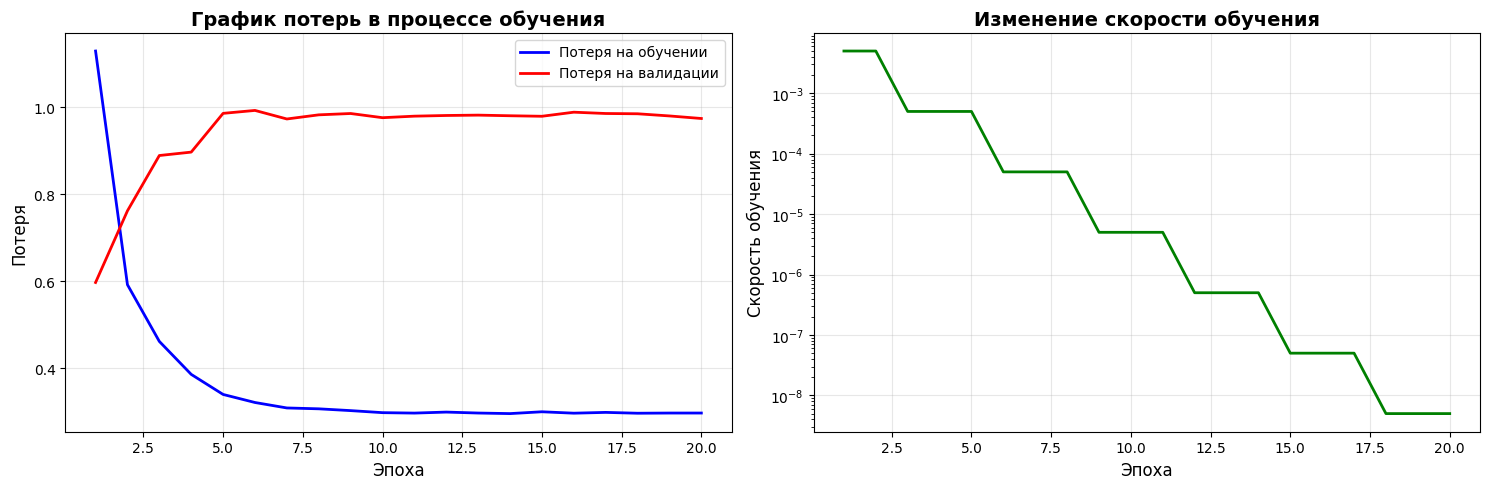

График сохранен в: /content/drive/MyDrive/rcnn_output/training_curves.png


In [12]:
# График потерь
plt.figure(figsize=(15, 5))

# График потери
plt.subplot(1, 2, 1)
epochs_range = range(1, NUM_EPOCHS + 1)
plt.plot(epochs_range, history['train_loss'], 'b-', label='Потеря на обучении', linewidth=2)
plt.plot(epochs_range, history['val_loss'], 'r-', label='Потеря на валидации', linewidth=2)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Потеря', fontsize=12)
plt.title('График потерь в процессе обучения', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# График скорости обучения
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['learning_rates'], 'g-', linewidth=2)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Скорость обучения', fontsize=12)
plt.title('Изменение скорости обучения', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'training_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

print('График сохранен в:', os.path.join(OUTPUT_PATH, 'training_curves.png'))

## 11. Оценка модели на тестовой выборке

In [13]:
# Загрузка лучшей модели
checkpoint = torch.load(os.path.join(OUTPUT_PATH, 'best_model.pth'))
model.load_state_dict(checkpoint['model_state_dict'])
print(f'Загружена лучшая модель (эпоха {checkpoint["epoch"]}, val_loss: {checkpoint["val_loss"]:.4f})')

# Оценка на валидационной выборке
print('\nОценка модели на валидационной выборке...')
val_metrics = evaluate_map(model, val_loader, device, iou_threshold=0.5, score_threshold=0.5)

print('\nМетрики на валидационной выборке:')
print(f"  Precision: {val_metrics['precision']:.4f}")
print(f"  Recall: {val_metrics['recall']:.4f}")
print(f"  F1-Score: {val_metrics['f1_score']:.4f}")
print(f"  True Positives: {val_metrics['true_positives']}")
print(f"  False Positives: {val_metrics['false_positives']}")
print(f"  False Negatives: {val_metrics['false_negatives']}")

# Оценка на тестовой выборке
print('\n' + '=' * 60)
print('Оценка модели на тестовой выборке...')
test_metrics = evaluate_map(model, test_loader, device, iou_threshold=0.5, score_threshold=0.5)

print('\nМетрики на тестовой выборке:')
print(f"  Precision: {test_metrics['precision']:.4f}")
print(f"  Recall: {test_metrics['recall']:.4f}")
print(f"  F1-Score: {test_metrics['f1_score']:.4f}")
print(f"  True Positives: {test_metrics['true_positives']}")
print(f"  False Positives: {test_metrics['false_positives']}")
print(f"  False Negatives: {test_metrics['false_negatives']}")
print('=' * 60)

# Сохранение метрик
metrics_report = {
    'validation': val_metrics,
    'test': test_metrics
}

with open(os.path.join(OUTPUT_PATH, 'metrics_report.json'), 'w') as f:
    json.dump(metrics_report, f, indent=2)

print('\nМетрики сохранены в:', os.path.join(OUTPUT_PATH, 'metrics_report.json'))

Загружена лучшая модель (эпоха 1, val_loss: 0.5972)

Оценка модели на валидационной выборке...


Оценка метрик: 100%|██████████| 2/2 [00:01<00:00,  1.60it/s]



Метрики на валидационной выборке:
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  True Positives: 0
  False Positives: 0
  False Negatives: 23

Оценка модели на тестовой выборке...


Оценка метрик: 100%|██████████| 20/20 [00:09<00:00,  2.04it/s]



Метрики на тестовой выборке:
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  True Positives: 0
  False Positives: 0
  False Negatives: 110

Метрики сохранены в: /content/drive/MyDrive/rcnn_output/metrics_report.json


## 12. Визуализация метрик качества

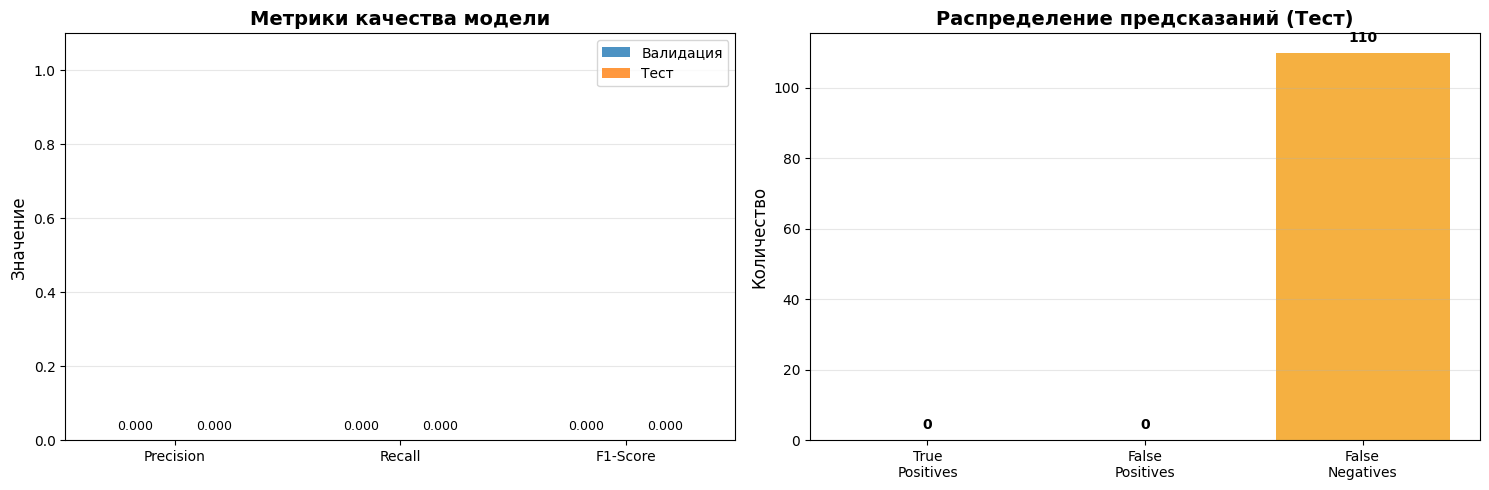

График метрик сохранен в: /content/drive/MyDrive/rcnn_output/metrics_visualization.png


In [14]:
# Визуализация метрик
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График 1: Precision, Recall, F1-Score
metrics_names = ['Precision', 'Recall', 'F1-Score']
val_values = [val_metrics['precision'], val_metrics['recall'], val_metrics['f1_score']]
test_values = [test_metrics['precision'], test_metrics['recall'], test_metrics['f1_score']]

x = np.arange(len(metrics_names))
width = 0.35

axes[0].bar(x - width/2, val_values, width, label='Валидация', alpha=0.8)
axes[0].bar(x + width/2, test_values, width, label='Тест', alpha=0.8)
axes[0].set_ylabel('Значение', fontsize=12)
axes[0].set_title('Метрики качества модели', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0, 1.1])

# Добавление значений на столбцы
for i, (v1, v2) in enumerate(zip(val_values, test_values)):
    axes[0].text(i - width/2, v1 + 0.02, f'{v1:.3f}', ha='center', va='bottom', fontsize=9)
    axes[0].text(i + width/2, v2 + 0.02, f'{v2:.3f}', ha='center', va='bottom', fontsize=9)

# График 2: True Positives, False Positives, False Negatives
categories = ['True\nPositives', 'False\nPositives', 'False\nNegatives']
test_counts = [
    test_metrics['true_positives'],
    test_metrics['false_positives'],
    test_metrics['false_negatives']
]

colors = ['#2ecc71', '#e74c3c', '#f39c12']
axes[1].bar(categories, test_counts, color=colors, alpha=0.8)
axes[1].set_ylabel('Количество', fontsize=12)
axes[1].set_title('Распределение предсказаний (Тест)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Добавление значений на столбцы
for i, count in enumerate(test_counts):
    axes[1].text(i, count + max(test_counts) * 0.02, str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'metrics_visualization.png'), dpi=300, bbox_inches='tight')
plt.show()

print('График метрик сохранен в:', os.path.join(OUTPUT_PATH, 'metrics_visualization.png'))

## 13. Визуализация предсказаний модели

Визуализация предсказаний на тестовых изображениях...



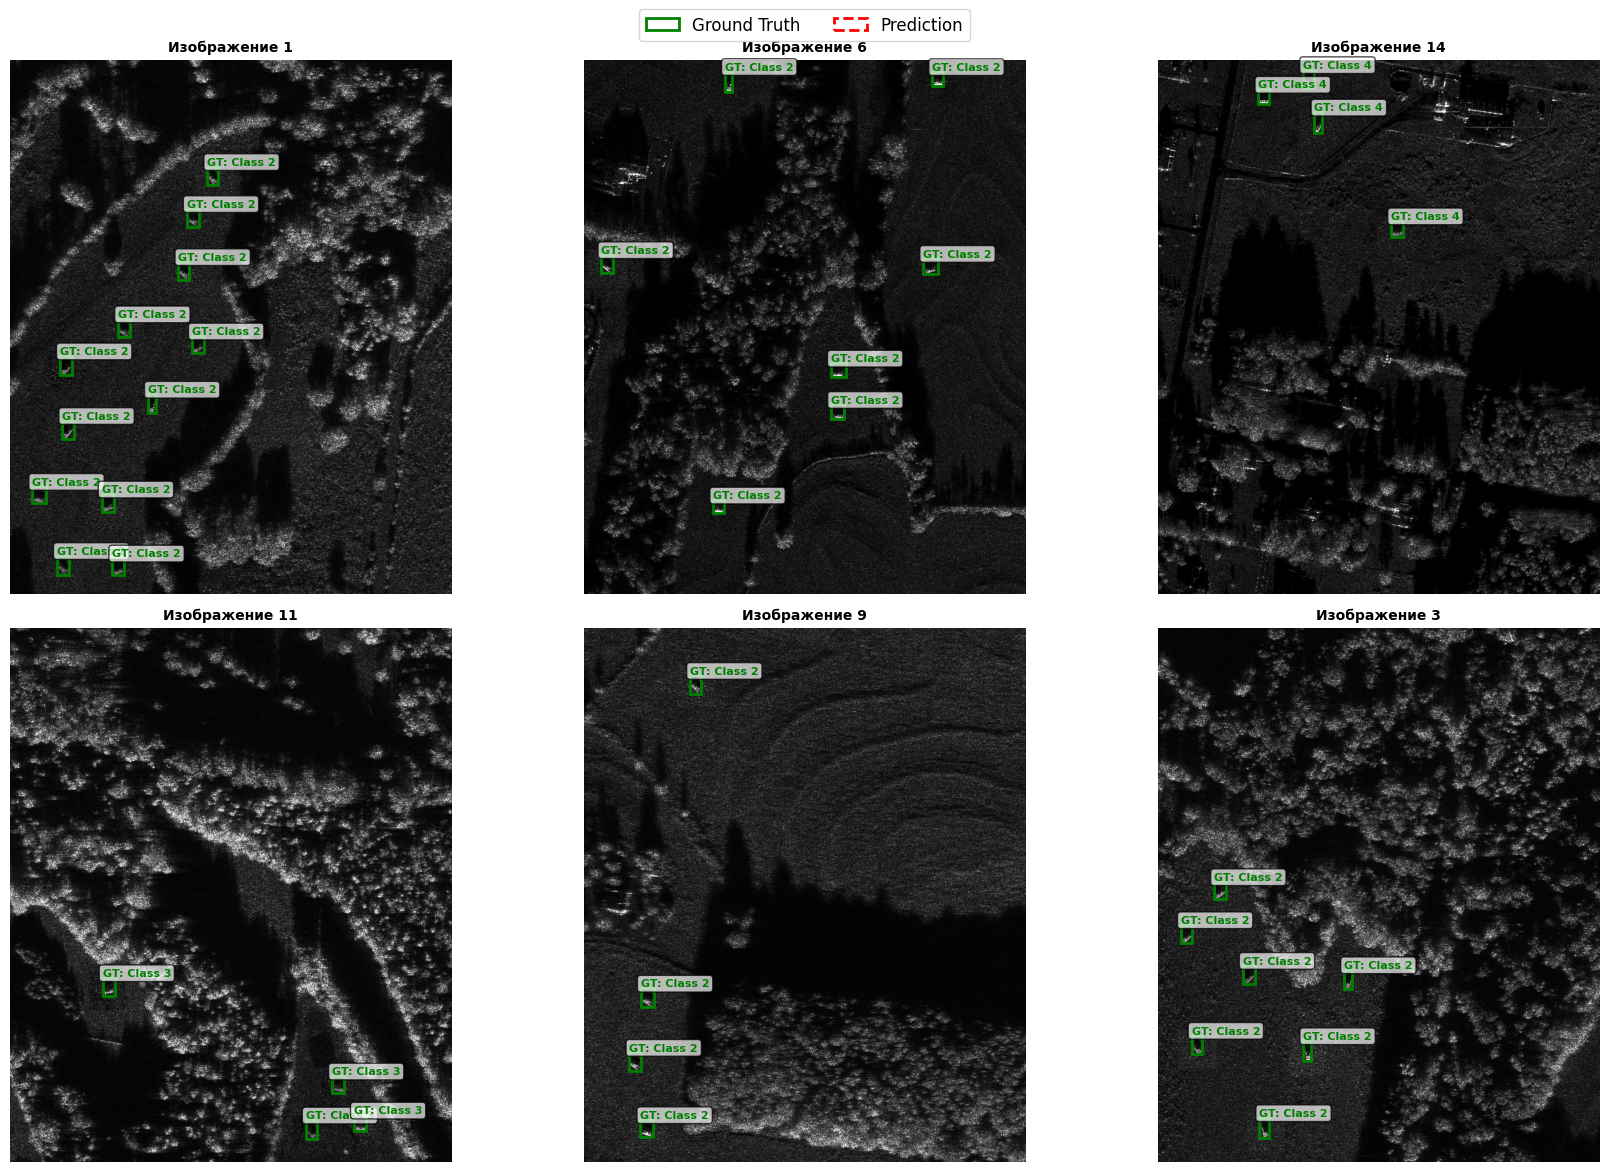

Визуализация сохранена в: /content/drive/MyDrive/rcnn_output/predictions_visualization.png


In [20]:
def visualize_predictions(model, dataset, device, num_images=6, score_threshold=0.5):
    """
    Визуализация предсказаний модели на тестовых изображениях.

    Args:
        model: обученная модель
        dataset: датасет для визуализации
        device: устройство
        num_images: количество изображений для визуализации
        score_threshold: порог уверенности для отображения предсказаний
    """
    model.eval()

    # Случайный выбор изображений
    indices = random.sample(range(len(dataset)), min(num_images, len(dataset)))

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for idx, img_idx in enumerate(indices):
        # Загрузка изображения и разметки
        image, target = dataset[img_idx]

        # Предсказание
        with torch.no_grad():
            prediction = model([image.to(device)])[0]

        # Преобразование изображения для отображения
        img_np = image.permute(1, 2, 0).cpu().numpy()

        # Отображение изображения
        axes[idx].imshow(img_np)
        axes[idx].axis('off')

        # Отрисовка ground truth боксов (зеленые)
        for box, label in zip(target['boxes'], target['labels']):
            box = box.cpu().numpy()
            rect = patches.Rectangle(
                (box[0], box[1]),
                box[2] - box[0],
                box[3] - box[1],
                linewidth=2,
                edgecolor='green',
                facecolor='none',
                label='Ground Truth' if idx == 0 and box is target['boxes'][0] else ''
            )
            axes[idx].add_patch(rect)

            # Подпись класса
            axes[idx].text(
                box[0], box[1] - 5,
                f'GT: Class {label.item()}',
                color='green',
                fontsize=8,
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
            )

        # Отрисовка предсказанных боксов (красные)
        pred_boxes = prediction['boxes'].cpu().numpy()
        pred_labels = prediction['labels'].cpu().numpy()
        pred_scores = prediction['scores'].cpu().numpy()

        for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
            if score > score_threshold:
                rect = patches.Rectangle(
                    (box[0], box[1]),
                    box[2] - box[0],
                    box[3] - box[1],
                    linewidth=2,
                    edgecolor='red',
                    facecolor='none',
                    linestyle='--',
                    label='Prediction' if idx == 0 and box is pred_boxes[0] else ''
                )
                axes[idx].add_patch(rect)

                # Подпись класса и уверенности
                axes[idx].text(
                    box[2], box[1] - 5,
                    f'Pred: Class {label} ({score:.2f})',
                    color='red',
                    fontsize=8,
                    fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7),
                    ha='right'
                )

        axes[idx].set_title(f'Изображение {img_idx + 1}', fontsize=10, fontweight='bold')

    # Легенда
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='none', edgecolor='green', linewidth=2, label='Ground Truth'),
        Patch(facecolor='none', edgecolor='red', linewidth=2, linestyle='--', label='Prediction')
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=12, bbox_to_anchor=(0.5, 0.98))

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(os.path.join(OUTPUT_PATH, 'predictions_visualization.png'), dpi=300, bbox_inches='tight')
    plt.show()

# Визуализация предсказаний на тестовой выборке
print('Визуализация предсказаний на тестовых изображениях...\n')
visualize_predictions(model, test_dataset, device, num_images=6, score_threshold=0.5)

print('Визуализация сохранена в:', os.path.join(OUTPUT_PATH, 'predictions_visualization.png'))

## 14. Функция инференса для новых изображений

In [16]:
def predict_image(model, image_path, device, score_threshold=0.5, class_names=None):
    """
    Предсказание объектов на новом изображении.

    Args:
        model: обученная модель
        image_path: путь к изображению
        device: устройство
        score_threshold: порог уверенности
        class_names: список названий классов

    Returns:
        boxes: координаты боксов
        labels: метки классов
        scores: уверенность предсказаний
    """
    model.eval()

    # Загрузка изображения
    image = Image.open(image_path).convert('RGB')
    img_tensor = torchvision.transforms.functional.to_tensor(image).to(device)

    # Предсказание
    with torch.no_grad():
        prediction = model([img_tensor])[0]

    # Фильтрация по порогу уверенности
    mask = prediction['scores'] > score_threshold
    boxes = prediction['boxes'][mask].cpu().numpy()
    labels = prediction['labels'][mask].cpu().numpy()
    scores = prediction['scores'][mask].cpu().numpy()

    # Визуализация
    plt.figure(figsize=(12, 8))
    plt.imshow(image)
    plt.axis('off')

    for box, label, score in zip(boxes, labels, scores):
        rect = patches.Rectangle(
            (box[0], box[1]),
            box[2] - box[0],
            box[3] - box[1],
            linewidth=3,
            edgecolor='red',
            facecolor='none'
        )
        plt.gca().add_patch(rect)

        # Название класса
        if class_names and label < len(class_names):
            class_name = class_names[label]
        else:
            class_name = f'Class {label}'

        plt.text(
            box[0], box[1] - 10,
            f'{class_name}: {score:.2f}',
            color='white',
            fontsize=12,
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='red', alpha=0.8)
        )

    plt.title('Обнаруженные объекты', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Вывод информации
    print(f'Обнаружено объектов: {len(boxes)}')
    for i, (box, label, score) in enumerate(zip(boxes, labels, scores), 1):
        if class_names and label < len(class_names):
            class_name = class_names[label]
        else:
            class_name = f'Class {label}'
        print(f'{i}. {class_name} - Уверенность: {score:.4f} - Координаты: {box}')

    return boxes, labels, scores

# Пример использования:
# Укажите список названий ваших классов (начиная с индекса 1, так как 0 - это фон)
# CLASS_NAMES = ['background', 'класс_1', 'класс_2', ...]
# predict_image(model, 'path/to/your/image.png', device, score_threshold=0.5, class_names=CLASS_NAMES)

print('\nФункция инференса готова к использованию!')
print('Для предсказания на новом изображении используйте:')
print('predict_image(model, "путь/к/изображению.png", device, score_threshold=0.5)')


Функция инференса готова к использованию!
Для предсказания на новом изображении используйте:
predict_image(model, "путь/к/изображению.png", device, score_threshold=0.5)


## 15. Сохранение и загрузка модели

In [17]:
# Функция для сохранения модели
def save_model(model, path, epoch=None, optimizer=None, metrics=None):
    """
    Сохранение модели и дополнительной информации.
    """
    checkpoint = {
        'model_state_dict': model.state_dict(),
    }

    if epoch is not None:
        checkpoint['epoch'] = epoch
    if optimizer is not None:
        checkpoint['optimizer_state_dict'] = optimizer.state_dict()
    if metrics is not None:
        checkpoint['metrics'] = metrics

    torch.save(checkpoint, path)
    print(f'Модель сохранена в: {path}')

# Функция для загрузки модели
def load_model(model, path, optimizer=None):
    """
    Загрузка модели.
    """
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])

    if optimizer is not None and 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    print(f'Модель загружена из: {path}')

    if 'epoch' in checkpoint:
        print(f'Эпоха: {checkpoint["epoch"]}')
    if 'metrics' in checkpoint:
        print(f'Метрики: {checkpoint["metrics"]}')

    return checkpoint

# Пример использования:
# Сохранение модели
# save_model(model, os.path.join(OUTPUT_PATH, 'my_model.pth'), epoch=NUM_EPOCHS, optimizer=optimizer, metrics=test_metrics)

# Загрузка модели
# model = create_model(NUM_CLASSES)
# checkpoint = load_model(model, os.path.join(OUTPUT_PATH, 'best_model.pth'))
# model.to(device)

print('\nФункции сохранения и загрузки модели готовы к использованию!')


Функции сохранения и загрузки модели готовы к использованию!


## Заключение

В этом ноутбуке мы реализовали полный пайплайн для обнаружения объектов с использованием R-CNN (Faster R-CNN):

1. ✅ Загрузка данных из Google Drive в формате YOLO
2. ✅ Создание кастомного Dataset для работы с изображениями и аннотациями
3. ✅ Построение модели Faster R-CNN с предобученным backbone
4. ✅ Обучение модели с валидацией
5. ✅ Визуализация графиков потерь и метрик
6. ✅ Оценка модели на тестовой выборке (Precision, Recall, F1-Score)
7. ✅ Визуализация предсказаний на изображениях
8. ✅ Функции для инференса на новых изображениях
9. ✅ Сохранение и загрузка обученной модели

### Важные замечания:

- Все файлы (модель, графики, метрики) сохраняются в папке, указанной в `OUTPUT_PATH`
- Модель автоматически сохраняет лучшие веса на основе валидационной потери
- Можно изменить гиперпараметры (количество эпох, batch size, learning rate) для улучшения результатов
- Для лучших результатов рекомендуется обучать модель дольше (30-50 эпох)
- Если не хватает памяти GPU, уменьшите `BATCH_SIZE`

### Следующие шаги:

1. Настройте `NUM_CLASSES` в соответствии с вашим датасетом
2. Укажите правильный путь к датасету в `DATASET_PATH`
3. Запустите все ячейки последовательно
4. Проанализируйте результаты и метрики
5. При необходимости настройте гиперпараметры и переобучите модель

Удачи в обучении модели! 🚀